In [ ]:
# Para subir archivos desde tu computador
from google.colab import files

uploaded = files.upload()



In [ ]:
import pandas as pd

# Ajusta el nombre del archivo si es distinto
df = pd.read_excel("00_base.xlsx")

# Revisamos estructura
df.head()

In [ ]:
# Aseguramos que el texto sea string
df["Spanish text"] = df["Spanish text"].astype(str)

# Texto limpio base
df["text_original"] = df["Spanish text"].str.replace("\n", " ")


In [ ]:
# Diccionario manual, pequeño y conservador
synonyms = {
    "artículos": "bienes",
    "materias primas": "insumos",
    "pago": "cancelación",
    "derechos": "gravámenes",
    "utilizadas": "empleadas",
    "introduzcan": "ingresen",
    "elaborados": "procesados"
}


In [ ]:
def synonym_substitution(text, synonyms):
    new_text = text
    for key, value in synonyms.items():
        new_text = new_text.replace(key, value)
    return new_text


In [ ]:
df["text_synonyms"] = df["text_original"].apply(
    lambda x: synonym_substitution(x, synonyms)
)


In [ ]:
import nltk
nltk.download("punkt")
from nltk.tokenize import sent_tokenize
import random

def shuffle_sentences(text):
    sentences = sent_tokenize(text)
    if len(sentences) > 2:
        middle = sentences[1:-1]
        random.shuffle(middle)
        sentences = [sentences[0]] + middle + [sentences[-1]]
    return " ".join(sentences)


In [ ]:
import nltk
nltk.download("punkt_tab")
df["text_shuffled"] = df["text_original"].apply(shuffle_sentences)

In [ ]:
!pip install transformers torch


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel


In [ ]:
def get_embeddings(texts, model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)

    embeddings = []

    for text in texts:
        inputs = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=512
        )

        with torch.no_grad():
            outputs = model(**inputs)

        # Mean pooling
        last_hidden = outputs.last_hidden_state
        embedding = last_hidden.mean(dim=1).squeeze().numpy()
        embeddings.append(embedding)

    return embeddings


In [ ]:
models = {
    "BETO": "dccuchile/bert-base-spanish-wwm-cased",
    "mBERT": "bert-base-multilingual-cased",
    "DistilBERT": "distilbert-base-multilingual-cased"
}


In [ ]:
results = {}

for model_name, model_path in models.items():
    print(f"Running model: {model_name}")

    emb_original = get_embeddings(df["text_original"].tolist(), model_path)
    emb_syn = get_embeddings(df["text_synonyms"].tolist(), model_path)
    emb_shuf = get_embeddings(df["text_shuffled"].tolist(), model_path)

    results[model_name] = {
        "original": emb_original,
        "synonyms": emb_syn,
        "shuffled": emb_shuf
    }


Running model: BETO


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def cosine_distance(a, b):
    return 1 - cosine_similarity([a], [b])[0][0]


In [ ]:
stability_results = []

for model_name in results:
    for i in range(len(df)):
        d_syn = cosine_distance(
            results[model_name]["original"][i],
            results[model_name]["synonyms"][i]
        )
        d_shuf = cosine_distance(
            results[model_name]["original"][i],
            results[model_name]["shuffled"][i]
        )

        stability_results.append({
            "model": model_name,
            "article": df.loc[i, "Article"],
            "distance_synonyms": d_syn,
            "distance_shuffle": d_shuf
        })


In [ ]:
stability_df = pd.DataFrame(stability_results)
stability_df.head()


,model,article,distance_synonyms,distance_shuffle
0,BETO,22,2.465725e-03,-1.192093e-07
1,BETO,27,5.110323e-03,2.980232e-07
2,BETO,28,5.580187e-04,0.000000e+00
3,BETO,37,1.281500e-03,7.649064e-04
4,BETO,34,7.152557e-07,7.152557e-07


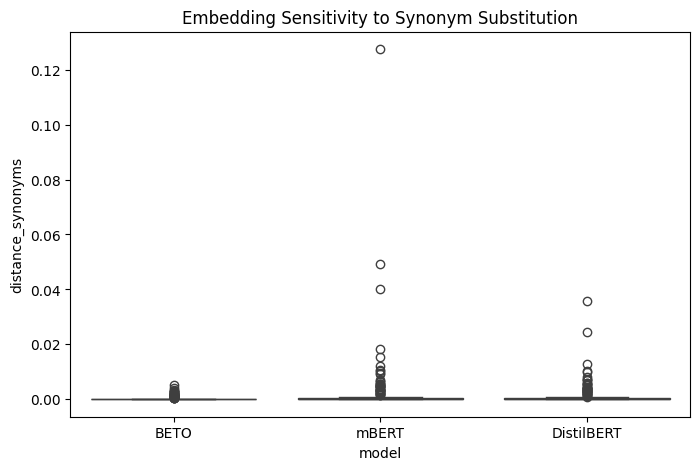

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(
    data=stability_df,
    x="model",
    y="distance_synonyms"
)
plt.title("Embedding Sensitivity to Synonym Substitution")
plt.show()


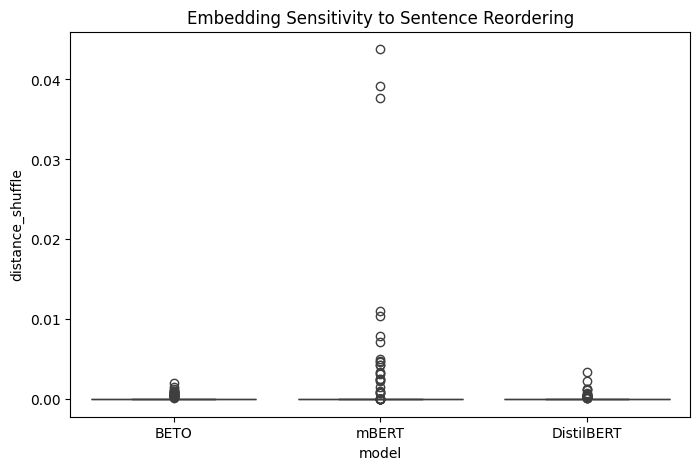

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=stability_df,
    x="model",
    y="distance_shuffle"
)
plt.title("Embedding Sensitivity to Sentence Reordering")
plt.show()
